# Document classification

**Recipe 05** · Level 1 (Beginner) · Decision type: `Choice`

Classify a short document as an invoice, meeting note, policy, technical guide, or other document type from its text.

Sources:

- S02: [TypeSafe AI: Primitives (Questions)](https://docs.typesafe.ai/primitives)
- S03: [TypeSafe AI: Confidence](https://docs.typesafe.ai/confidence)
- S07: [TypeSafe AI: Jev 1.13 jaggedness](https://docs.typesafe.ai/model-jaggedness/jev-1.13)

## What you will build

A small document-type classifier. Jev reads one short document and picks exactly one of five options: `invoice`, `meeting_note`, `policy`, `technical_guide`, or `other`, the fallback this use case names for anything that is not one of the first four. Python decides nothing about the document's content; it only decides whether an answer is confident enough to report on its own, or should go to an explicit review outcome instead. By the end you will have looked at individual typed answers, including two genuinely borderline documents and one the stored answer gets wrong with confidence, seen the rule that acts on them, and run an evaluation that chooses its one setting on `validation` and reports on `test`.

## Setup and run mode

The notebook runs from its own folder with the standard library and `jev_cookbook` only. `get_backend(fixtures=...)` replays the 40 stored answers in `fixtures/responses.json` offline; setting `JEV_COOKBOOK_LIVE=1` (see the README) swaps in live calls to the same question definitions and changes nothing else. `run_header` states which mode ran, and every number below carries that mode with it.

In [1]:
from jev_cookbook import get_backend, load_helpers
from jev_cookbook.evaluation import (
    accuracy,
    confusion_matrix,
    evaluate_selective,
    per_class_metrics,
    select_confidence_threshold,
)
from jev_cookbook.fixtures import load_inputs, load_labels, responses_path, select_split
from jev_cookbook.style import (
    apply_style,
    plot_answer_probabilities,
    plot_confusion_matrix,
    run_header,
    show_answer,
)

apply_style()
helpers = load_helpers()  # this recipe's helpers.py, loaded by path
examples = load_inputs()
labels = load_labels()
backend = get_backend(fixtures=responses_path())
# N for the header is the number of examples the metrics are about: validation and test. This
# recipe has no train split; demo examples are shown but never scored.
scored = [e for e in examples if e.split not in ("train", "demo")]

offline = backend.mode in ("synthetic", "scripted")
check = " (a pipeline check, not a Jev result)" if offline else ""
# CONTRIBUTING.md section 2: "a number from the validation split is a selection step, not a
# result." This label does not depend on the run mode, unlike `check` above: even a recorded or
# live run must not print a bare validation number.
selection = " (a selection step, not a reported result)"

# Every one of the 40 examples in fixtures/ needs at most one request. This cache makes sure a
# document that is shown individually and later scored in its split is decided once, so the
# whole notebook makes exactly 40 requests in live mode, never more.
answered = {}


def decide(example):
    if example.id not in answered:
        answered[example.id] = backend.decide(helpers.build_state(example.fields), questions)[
            "doc_type"
        ]
    return answered[example.id]


run_header(
    5,
    "Document classification",
    backend=backend,
    n_examples=len(scored),
)

Recipe 05: Document classification
Mode: offline replay of synthetic fixtures, pipeline check on a fixture sample of 38 examples
Metrics in this run are checks that the pipeline works. They are not Jev results.


## The state

The state is everything Jev sees, and Python builds it. Each example in `fixtures/inputs.jsonl` carries `fields`: a `doc_id` and the document `text`. `build_state` passes on the text only; the identifier stays in Python and is attached to the outcome at the end, so it never passes through the model and every result still traces back to its document.

In [2]:
import json

demo = {e.id: e for e in examples if e.split == "demo"}
example = demo["d01-meeting-vs-policy"]
print("Python has:")
print(json.dumps(example.fields, indent=2))
state = helpers.build_state(example.fields)
print("Jev sees:")
print(json.dumps(state, indent=2))

Python has:
{
  "doc_id": "D301",
  "text": "At Tuesday's staff meeting, Finance proposed that any expense report over $500 must have manager approval before submission. Starting next week, this applies to every department, and expense reports without the approval signature will be returned unprocessed."
}
Jev sees:
{
  "text": "At Tuesday's staff meeting, Finance proposed that any expense report over $500 must have manager approval before submission. Starting next week, this applies to every department, and expense reports without the approval signature will be returned unprocessed."
}


## The questions

There is one question, and it asks one thing: what type of document is this? A `Choice` fits because the five outcomes are exclusive and Jev should commit to exactly one. The option set is fixed to the four document types the catalog's use case names, `invoice`, `meeting_note`, `policy`, `technical_guide`, plus `other`, the fallback the use case names explicitly for "an invoice, meeting note, policy, technical guide, or other document type". Every option is a label Python is willing to report, including `other`: a classifier free to invent its own categories cannot be compared against a fixed set of gold labels, and a use case with no fallback would force every odd document into one of the four named types.

Three pairs of options are easy to confuse, and each description says what belongs to its own option and, for that pair, what belongs to the other one instead: `invoice`/`other` (a paid receipt is not a bill requesting payment), `meeting_note`/`policy` (minutes that report a decision as something that happened are not the same as a standing rule, even when the rule mentions the meeting that approved it), and `policy`/`technical_guide` (a mandate with no steps to follow is not a guide). TypeSafe's notes on Jev 1.13 (S07, item 1, "literal reading") say the model answers the question you wrote, not the one you meant: a `policy` description that only said "a standing rule" would be read exactly that literally, and a document that happens to mention a meeting would plausibly match a vague `meeting_note` description too, for no better reason than that one word appears in both. The second sentence in each description exists to close that gap.

A `Choice` answer's `confidence` is the top probability rescaled by the number of options, `(p_max - 1/n) / (1 - 1/n)`: with five options, `1/n = 0.2`, so confidence is 0 when the top option has no more than an even one-fifth share, 1 when one option holds all the probability. It depends only on that top probability; it does not look at how the remaining probability is spread across the other four options, so two answers with the same top probability have the same confidence whether the rest is spread evenly or piled onto a single runner-up. A low confidence here does not mean a document is unreadable; it means the top option did not clear much more than an even share.

Option order is part of a `Choice`'s replay key ([docs/backends.md](../../docs/backends.md)): the key is a hash of the state and the exact questions asked, options included in the order written, so reordering `OPTIONS` would invalidate every stored response in `fixtures/responses.json`. That is why "The questions" settles this recipe's option order once, here, rather than leaving it to be changed later without noticing the cost.

In [3]:
questions = helpers.build_questions()
doc_type = questions["doc_type"]
print(doc_type.instructions)
for name, description in doc_type.criteria.items():
    print(f"  {name:16s} {description}")

What type of document is this?
  invoice          A bill requesting payment for specific goods or services: it names an amount owed and, usually, a due date or an invoice number. A receipt confirming a payment already made is not an invoice; nothing further is being requested, so that belongs to other.
  meeting_note     A record of one specific meeting that took place: who attended or spoke, and what was discussed, decided, or assigned there. A document whose main content is a standing rule that merely mentions being approved at a meeting belongs to policy, not here.
  policy           A standing rule or requirement that governs behavior or process going forward, stated as an obligation ('must', 'is required to', 'will not be permitted to'), independent of any single meeting or event. Minutes that report a decision as something that happened belong to meeting_note; a document whose main content is the rule itself, even if it says when or where it was approved, belongs here.
  technica

### How the descriptions change the answer on a borderline document

The memo shown next, below under "One answer up close", reads: "At Tuesday's staff meeting, Finance proposed that any expense report over $500 must have manager approval before submission. Starting next week, this applies to every department, and expense reports without the approval signature will be returned unprocessed." It opens with "At Tuesday's staff meeting", which is exactly the kind of wording a bare `meeting_note` description ("a record of a meeting") would match on its face, by S07 item 1's literal reading: nothing in a description that stops there tells the model that mentioning a meeting is not enough. The description actually used above adds a second sentence to both `meeting_note` and `policy` for exactly this reason: `meeting_note` says a document whose main content is a standing rule belongs to `policy` instead, even if it mentions being approved at a meeting; `policy` says the reverse. What decides this memo is not the opening clause but the rest of it, "applies to every department", "starting next week", "will be returned unprocessed": an ongoing requirement, not a record of what was discussed. The stored answer below, which uses the actual (sharper) descriptions, puts `policy` only narrowly ahead of `meeting_note`; without the second sentence in each description, nothing here would have told the model which half of the memo was supposed to decide it, and the two options could plausibly have tied or swapped places. That last claim is a design argument about the question, not a measurement: this notebook never asks the model anything under the weaker wording, offline or otherwise, so nothing here shows what would actually have happened, only why the second sentence was added.

## One answer up close

Before any aggregate number, look at three typed answers: the memo just discussed, a short payment confirmation that could plausibly be read as an invoice, and a `validation` document this recipe gets wrong on purpose, to show what a frozen threshold does not catch even on the split where it is chosen. (`test` is not touched until "Evaluation", after that threshold is frozen: `CONTRIBUTING.md` §2 keeps a held-out split used once.) Each answer holds the chosen option, a probability for every option, the `confidence` explained above, and a `provenance` line that says where the answer came from, here always `synthetic`, since nothing in this recipe's fixtures came from a real call.

At Tuesday's staff meeting, Finance proposed that any expense report over $500 must have manager approval before submission. Starting next week, this applies to every department, and expense reports without the approval signature will be returned unprocessed.
Choice: policy (confidence 0.33)
  policy           0.46  #########
  meeting_note     0.40  ########
  technical_guide  0.06  #
  invoice          0.04  #
  other            0.04  #
Provenance: synthetic


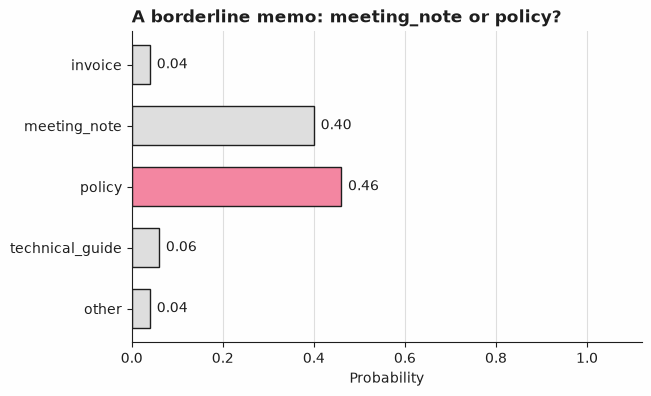

In [4]:
memo_example = demo["d01-meeting-vs-policy"]
memo_answer = decide(memo_example)
print(memo_example.fields["text"])
show_answer(memo_answer)
plot_answer_probabilities(memo_answer, title="A borderline memo: meeting_note or policy?")

`policy` leads at 0.46, with `meeting_note` close behind at 0.40, so `confidence` is only 0.325: `(0.46 - 0.2) / 0.8`. That is exactly the close call the previous cell's discussion predicted: the opening clause pulls toward `meeting_note`, the rest of the memo pulls toward `policy`, and the stored answer puts the two within six points of each other. This document has no gold label (it is a `demo` example, never scored); it exists to show what a genuinely borderline case looks like in the typed answer itself, not to be counted right or wrong.

In [5]:
receipt_example = demo["d02-invoice-vs-other"]
receipt_answer = decide(receipt_example)
print(receipt_example.fields["text"])
show_answer(receipt_answer)

Thank you for your payment of $64.00 for invoice #312. This confirms the invoice is now paid in full.
Choice: other (confidence 0.35)
  other            0.48  ##########
  invoice          0.42  ########
  technical_guide  0.04  #
  meeting_note     0.03  #
  policy           0.03  #
Provenance: synthetic


"Thank you for your payment of $64.00 for invoice #312. This confirms the invoice is now paid in full." mentions an invoice number and a dollar amount, exactly the surface features `invoice`'s description names, but it is confirming a payment already received, not requesting one: by the `invoice` description above, that is `other`, not `invoice`. The stored answer agrees, `other` at 0.48 against `invoice` at 0.42, confidence 0.35: close, because the document genuinely shares surface features with an invoice, but on the right side of the line the description draws.

In [6]:
hard_example = next(e for e in examples if e.id == "v12-deploy")
hard_answer = decide(hard_example)
print(hard_example.fields["text"])
show_answer(hard_answer)

All production deployments must go through the automated release pipeline; manual deployment to production is not permitted under any circumstance.
Choice: technical_guide (confidence 0.47)
  technical_guide  0.58  ############
  policy           0.30  ######
  other            0.06  #
  invoice          0.03  #
  meeting_note     0.03  #
Provenance: synthetic


"All production deployments must go through the automated release pipeline; manual deployment to production is not permitted under any circumstance." has no steps to follow, only an ongoing mandate, which is exactly `policy` by the description above; this recipe's gold label agrees. The stored answer calls it `technical_guide` instead: "the automated release pipeline" and "manual deployment" can read like the subject of a procedure rather than the rule governing one. This is a `validation` document, the split the next section chooses its threshold on, and the evaluation there counts this one as wrong on purpose: a fixture set where `validation` is always right would hide the fact that the split used to choose a threshold is not itself immune to accepting a wrong answer. Nothing here says *why* a real model would get this one wrong, because nothing here is a real model: the probabilities were written by hand for this fixture, not produced by Jev.

## Python's part

Jev supplies the judgment; what happens with it is code. `classify` in `helpers.py` accepts the chosen document type as given when the answer's confidence is at or above a threshold, and sends it to an explicit `review` outcome otherwise, whatever the type is: every option here is one Python is willing to report, so confidence is the only thing the rule checks. `tests/test_helpers.py` checks the rule at the boundary, outside `0` to `1`, and for a low-confidence answer of every one of the five labels, so a rule that quietly exempted one label from the threshold would fail it.

The threshold itself is chosen here, on `validation`, and then frozen for the rest of this notebook: `select_confidence_threshold` picks the lowest threshold (so the highest coverage) whose accepted subset reaches at least 90% accuracy on the 19 `validation` documents. A looser target than "perfectly accurate", on purpose: this fixture set includes one confidently wrong `validation` answer (the deployment-pipeline memo above), and a target of 100% would force the threshold above it, hiding the fact that the split used to choose the threshold is not itself immune to accepting a wrong answer. At 90%, the lowest threshold that clears it turns out to be the lowest confidence observed anywhere in `validation`, so every `validation` document, including that wrong one, ends up accepted; nothing on `validation` goes to `review` at this target. Applying the frozen threshold to the three answers shown above, plus one clearly confident and correct document for contrast, shows both outcomes the rule can produce.

In [7]:
val_examples = select_split(examples, "validation")
val_answers = [decide(e) for e in val_examples]
val_gold = [labels[e.id] for e in val_examples]
val_correct = [a.choice == g for a, g in zip(val_answers, val_gold, strict=True)]
val_confidence = [a.confidence for a in val_answers]
threshold = select_confidence_threshold(val_correct, val_confidence, target_accuracy=0.90)
print(f"chosen threshold, frozen from here on: {threshold:.4f}{selection}")

confident_example = next(e for e in val_examples if e.id == "v01-invoice")
confident_answer = decide(confident_example)
for shown_example, shown_answer in (
    (memo_example, memo_answer),
    (receipt_example, receipt_answer),
    (hard_example, hard_answer),
    (confident_example, confident_answer),
):
    result = helpers.classify(shown_example.fields["doc_id"], shown_answer, threshold)
    print(
        f"{result.doc_id}: {shown_answer.choice} at confidence {shown_answer.confidence:.2f} "
        f"-> {result.outcome} ({result.reason})"
    )

chosen threshold, frozen from here on: 0.4000 (a selection step, not a reported result)
D301: policy at confidence 0.33 -> review (confidence below the threshold)
D302: other at confidence 0.35 -> review (confidence below the threshold)
D112: technical_guide at confidence 0.47 -> accepted (confident)
D101: invoice at confidence 0.85 -> accepted (confident)


## Evaluation

The threshold was chosen and frozen above, on `validation`. This section reports what the frozen rule does: `helpers.classify` is applied to every example in `validation` and in `test`, and the counts below come from what it actually returns, not from a separate reimplementation of the same condition. Alongside that, `jev_cookbook.evaluation` reports accuracy of the raw choice, a confusion matrix against the gold types, per-class precision and recall with the one confusable pair discussed on its own, and the coverage, accuracy and risk the frozen threshold produces. In an offline run every `test` number here is a check that the pipeline works, and it says so; every `validation` number, in every run mode, is a selection step rather than a reported result, which is why it carries a different label.

In [8]:
def report(chosen, decided, gold, threshold):
    """Apply classify to every answer and tally what it actually did."""
    results = [
        helpers.classify(e.fields["doc_id"], a, threshold)
        for e, a in zip(chosen, decided, strict=True)
    ]
    accepted = [
        (a, g)
        for r, a, g in zip(results, decided, gold, strict=True)
        if r.outcome == helpers.ACCEPTED
    ]
    right = sum(a.choice == g for a, g in accepted)
    reasons = {}
    for r in results:
        if r.outcome == helpers.REVIEW:
            reasons[r.reason] = reasons.get(r.reason, 0) + 1
    return results, len(accepted), right, reasons


_, n_accepted, n_right, val_reasons = report(val_examples, val_answers, val_gold, threshold)
print(f"validation, {len(val_examples)} examples{selection}")
print(f"accuracy of the choice: {accuracy(val_gold, val_answers):.4f}{selection}")
print(f"accepted by the rule at this threshold: {n_accepted} of {len(val_examples)}{selection}")
print(f"right among those accepted: {n_right} of {n_accepted}{selection}")
print(f"review reasons: {val_reasons or 'none'}{selection}")

validation, 19 examples (a selection step, not a reported result)
accuracy of the choice: 0.9474 (a selection step, not a reported result)
accepted by the rule at this threshold: 19 of 19 (a selection step, not a reported result)
right among those accepted: 18 of 19 (a selection step, not a reported result)
review reasons: none (a selection step, not a reported result)


test, 19 examples, threshold 0.4000 frozen (a pipeline check, not a Jev result)
accuracy of the choice: 0.9474 (a pipeline check, not a Jev result)
accepted by the rule: 16 of 19 (a pipeline check, not a Jev result)
right among those accepted: 15 of 16 (a pipeline check, not a Jev result)
review reasons: {'confidence below the threshold': 3} (a pipeline check, not a Jev result)


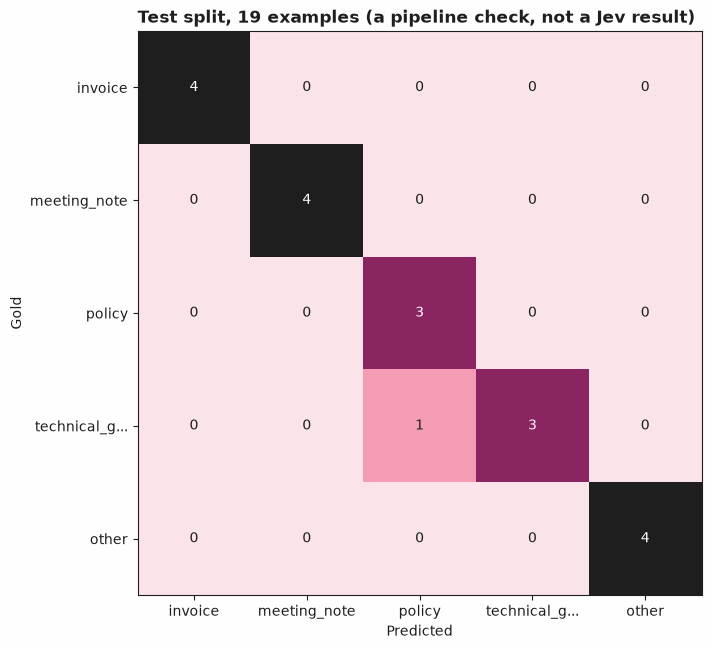

In [9]:
test_examples = select_split(examples, "test")
test_answers = [decide(e) for e in test_examples]
test_gold = [labels[e.id] for e in test_examples]

_, n_accepted_t, n_right_t, test_reasons = report(test_examples, test_answers, test_gold, threshold)
print(f"test, {len(test_examples)} examples, threshold {threshold:.4f} frozen{check}")
print(f"accuracy of the choice: {accuracy(test_gold, test_answers):.4f}{check}")
print(f"accepted by the rule: {n_accepted_t} of {len(test_examples)}{check}")
print(f"right among those accepted: {n_right_t} of {n_accepted_t}{check}")
print(f"review reasons: {test_reasons or 'none'}{check}")

matrix = confusion_matrix(
    test_gold,
    test_answers,
    labels=["invoice", "meeting_note", "policy", "technical_guide", "other"],
)
plot_confusion_matrix(matrix, title=f"Test split, {len(test_examples)} examples{check}")

`test` has exactly **one** misclassification: an account-reset procedure, "Resetting a locked account: verify the requester's identity with two forms of ID, reset the password in the admin console, then require a new passphrase on next login," whose ordered steps are addressed to whoever performs the task, which is `technical_guide` by the description above and by this recipe's gold label; the stored answer calls it `policy` instead, at confidence 0.525: the document was written to be readable as a mandate (a security procedure with the word "require" in it), which is why this fixture's answer was written that way, not because a real model read it that way. That is the mirror image of the deployment-pipeline memo shown earlier, which is `policy` by gold and description but was called `technical_guide`: the same pair, confused in opposite directions, but on different splits, not twice within `test`.

TypeSafe's notes on Jev 1.13 (S07, item 8) document that a `Choice` answer can lean toward whichever option comes first in the list it is given; `OPTIONS` here is ordered `invoice, meeting_note, policy, technical_guide, other`. `test`'s one error predicts `policy` (third) for a document whose gold is `technical_guide` (fourth), which *is* toward the earlier of the two; `validation`'s error above goes the other way, predicting `technical_guide` for a document whose gold is `policy`. Two confidently-wrong answers, each moving toward a different option in the order, is the cleanest result this fixture set could show about option order: it carries no signal either way, because each hand-written probability vector is one data point, not a pattern, and nothing here was produced by a model in the first place. It is worth naming the limitation anyway, because it is a real, documented reason to reorder `OPTIONS` and check that an answer stays consistent if this recipe is ever run live; "The questions" above explains why that is not free here.

For each class, `precision` is the fraction of the rule's calls of that type that were actually right, and `recall` is the fraction of that type's real `test` documents the rule found at all; `f1` is their harmonic mean, a single number that is low whenever either one is, and `support` is how many `test` documents actually carry that gold type, so a recall figure is only as meaningful as its support is large.

In [10]:
per_class = per_class_metrics(
    test_gold,
    test_answers,
    labels=["invoice", "meeting_note", "policy", "technical_guide", "other"],
)
for label, counts in per_class.items():
    print(
        f"{label:16s} precision {counts.precision:.3f}  recall {counts.recall:.3f}  "
        f"f1 {counts.f1:.3f}  support {counts.support}{check}"
    )

invoice          precision 1.000  recall 1.000  f1 1.000  support 4 (a pipeline check, not a Jev result)
meeting_note     precision 1.000  recall 1.000  f1 1.000  support 4 (a pipeline check, not a Jev result)
policy           precision 0.750  recall 1.000  f1 0.857  support 3 (a pipeline check, not a Jev result)
technical_guide  precision 1.000  recall 0.750  f1 0.857  support 4 (a pipeline check, not a Jev result)
other            precision 1.000  recall 1.000  f1 1.000  support 4 (a pipeline check, not a Jev result)


`policy` and `technical_guide` are the one pair with any `test` error, and it is a single document doing double duty: the account-reset guide above is gold `technical_guide` but predicted `policy`, which is exactly one miss out of `technical_guide`'s four `test` documents (recall 0.75) and exactly one wrong call out of the four documents predicted `policy`, three of them rightly so (precision 0.75). `policy`'s own three `test` documents are all found (recall 1.000). Every other class, `invoice`, `meeting_note`, and `other`, is perfectly recovered on `test`: this fixture set only put ambiguity into the one pair whose descriptions explicitly call each other out, and on `test` that ambiguity cost exactly one document, not two.

The `accepted`/`review` counts above come straight from `classify`; `evaluate_selective` reports the same split through `jev_cookbook.evaluation`'s own vocabulary. `coverage` is the fraction of all nineteen `test` documents that clear the threshold and get a reported type; among those, `accuracy` is the fraction that are right, and `risk` is its complement, `1 - accuracy`, the fraction that are wrong despite having cleared the bar.

In [11]:
test_correct = [a.choice == g for a, g in zip(test_answers, test_gold, strict=True)]
test_confidence = [a.confidence for a in test_answers]
selective = evaluate_selective(test_correct, test_confidence, threshold)
print(
    f"answered: {selective.n_answered} of {selective.n_total} "
    f"(coverage {selective.coverage:.4f}){check}"
)
print(f"accuracy among those answered: {selective.accuracy:.4f}{check}")
print(f"risk among those answered: {selective.risk:.4f}{check}")

answered: 16 of 19 (coverage 0.8421) (a pipeline check, not a Jev result)
accuracy among those answered: 0.9375 (a pipeline check, not a Jev result)
risk among those answered: 0.0625 (a pipeline check, not a Jev result)


At this threshold, two documents below the review bar are genuinely hard to read ("Backups must be encrypted...", `policy`/`technical_guide`-adjacent at confidence 0.375, and "At the deployment retro...", `meeting_note`/`technical_guide`-adjacent, also at confidence 0.375) and one is the very short "See attached." (confidence 0.025); all three go to `review` instead of being reported as a result, which is the coverage this recipe's `test` split gives up, 16 of 19 documents, 0.8421. All three are also correct as stored (`meeting_note`, `policy`, and `other`, each matching its gold label): the gate removes three right answers and admits no wrong one, since the account-reset guide, `test`'s one actual error, is wrong at confidence 0.525, comfortably above the 0.40 threshold frozen on `validation`, so the rule accepts it anyway. That is the whole story behind `risk` above being 0.0625 and not 0, and it is also why accepted accuracy (0.9375) is *lower* than the raw choice accuracy two cells up (0.9474): on this fixture set the threshold buys no accuracy at all, only less coverage. The same shape appears on `validation`, for a different reason: the deployment-pipeline memo above (`v12-deploy`) is wrong at confidence 0.475, also above 0.40, and nothing on `validation` falls below 0.40 to begin with (the "Python's part" section above says why), so that split's one error is accepted too, and `validation`'s own accepted accuracy, 0.9474, is not 1.0, with risk 0.0526. A threshold chosen to clear 90% accuracy on `validation` is a guarantee about `validation` at that bar, not a promise that every accepted answer, on `validation` or on `test`, is correct.

## What was and was not measured

Measured: that the pipeline runs end to end, and that the rule and the evaluation behave as designed on 38 scored documents (plus 2 more, shown in this notebook but never scored). Not measured: anything about how Jev performs, how fast it is, or what it costs. The stored answers in the offline run are written by hand as probabilities, some of them wrong on purpose (including two wrong *and* confident, one in each split, to show what a frozen threshold does not catch), so every number above describes this fixture set and not a model.

In [12]:
if offline:
    print(f"Provenance: {backend.mode}. Not measured live: a pipeline check, not a Jev result.")
else:
    dates = ", ".join(getattr(backend, "recorded_dates", ()) or ()) or "this run"
    print(f"Provenance: {backend.mode}, model {backend.model}")
    print(f"Captured: {dates}")
    print(f"N: {len(val_examples)} validation and {len(test_examples)} test examples")

Provenance: synthetic. Not measured live: a pipeline check, not a Jev result.


## Next steps

- Add a hard document to `ROWS` in `build_fixtures.py` with the answer you expect a model might give, run `python build_fixtures.py`, and see where `classify` sends it.
- Change the threshold's target in the evaluation cell (`target_accuracy=0.90` to something tighter or looser) and see how coverage, accuracy and the review count trade off.
- Neighbouring recipes: [`01-sentiment-classification`](../01-sentiment-classification/) and [`04-support-ticket-routing`](../04-support-ticket-routing/), both a `Choice` over a fixed option set like this one, and [`06-multiple-topic-labels`](../06-multiple-topic-labels/), which asks one independent `Noul` question per label instead of a single `Choice` when a document can genuinely belong to more than one category at once.